# Построение слоя городских кварталов

In [ ]:
#%pip install numpy==2.1.3 scipy==1.14.1 folium==0.17.0 --force-reinstall --no-cache-dir

     --------------------------------------- 12.9/12.9 MB 40.9 MB/s eta 0:00:00
     --------------------------------------- 44.8/44.8 MB 16.0 MB/s eta 0:00:00
     ---------------------------------------- 108.4/108.4 kB ? eta 0:00:00
     -------------------------------------- 134.9/134.9 kB 7.8 MB/s eta 0:00:00
     ---------------------------------------- 64.7/64.7 kB ? eta 0:00:00
     ---------------------------------------- 93.9/93.9 kB ? eta 0:00:00
     ---------------------------------------- 107.0/107.0 kB ? eta 0:00:00
     ---------------------------------------- 71.0/71.0 kB ? eta 0:00:00
     ---------------------------------------- 131.1/131.1 kB ? eta 0:00:00
     ---------------------------------------- 159.4/159.4 kB ? eta 0:00:00
  Attempting uninstall: xyzservices
    Found existing installation: xyzservices 2025.11.0
    Uninstalling xyzservices-2025.11.0:
      Successfully uninstalled xyzservices-2025.11.0
  Attempting uninstall: urllib3
    Found existing instal

  Consider adding this directory to PATH or, if you prefer to suppress this warning, use --no-warn-script-location.
  Consider adding this directory to PATH or, if you prefer to suppress this warning, use --no-warn-script-location.
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
popframe 0.0.9 requires folium==0.14.0, but you have folium 0.17.0 which is incompatible.
popframe 0.0.9 requires networkx==3.1, but you have networkx 3.6 which is incompatible.
popframe 0.0.9 requires numpy==1.23.5, but you have numpy 2.1.3 which is incompatible.
popframe 0.0.9 requires pandas==1.5.3, but you have pandas 2.3.3 which is incompatible.
popframe 0.0.9 requires pyarrow==12.0.0, but you have pyarrow 19.0.1 which is incompatible.
popframe 0.0.9 requires requests==2.31.0, but you have requests 2.32.5 which is incompatible.
popframe 0.0.9 requires scikit-learn==1.2.2, but you h

In [ ]:
#%pip install blocksnet[ipynb,torch]==1.0.0.a8 -q

Note: you may need to restart the kernel to use updated packages.


ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
popframe 0.0.9 requires geopandas==0.13.0, but you have geopandas 1.1.1 which is incompatible.
popframe 0.0.9 requires matplotlib==3.7.1, but you have matplotlib 3.10.7 which is incompatible.
popframe 0.0.9 requires networkx==3.1, but you have networkx 3.6 which is incompatible.
popframe 0.0.9 requires numpy==1.23.5, but you have numpy 2.1.3 which is incompatible.
popframe 0.0.9 requires osmnx==1.6.0, but you have osmnx 2.0.7 which is incompatible.
popframe 0.0.9 requires pandas==1.5.3, but you have pandas 2.3.3 which is incompatible.
popframe 0.0.9 requires pyarrow==12.0.0, but you have pyarrow 19.0.1 which is incompatible.
popframe 0.0.9 requires requests==2.31.0, but you have requests 2.32.5 which is incompatible.
popframe 0.0.9 requires scikit-learn==1.2.2, but you have scikit-learn 1.7.2 which is incompatible

In [8]:
import blocksnet

## 1. Генерация слоя городских кварталов

Если уже ЕСТЬ, то можно пропустить этот этап.

### 1.1. Загрузка данных

In [9]:
import osmnx as ox

boundaries_gdf = ox.geocode_to_gdf('Екатеринбург')

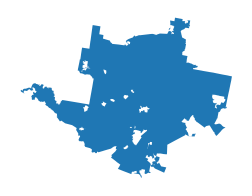

In [10]:
ax = boundaries_gdf.plot(figsize=(3,3))
ax.set_axis_off()

In [3]:
BC_TAGS = {
    'roads': {
      "highway": ["construction","crossing","living_street","motorway","motorway_link","motorway_junction","pedestrian","primary","primary_link","raceway","residential","road","secondary","secondary_link","services","tertiary","tertiary_link","track","trunk","trunk_link","turning_circle","turning_loop","unclassified",],
      "service": ["living_street", "emergency_access"]
    },
    'railways': {
      "railway": "rail"
    },
    'water': {
      'riverbank':True,
      'reservoir':True,
      'basin':True,
      'dock':True,
      'canal':True,
      'pond':True,
      'natural':['water','bay'],
      'waterway':['river','canal','ditch'],
      'landuse':'basin',
      'water': 'lake'
    }
}

In [11]:
boundaries_geom = boundaries_gdf.union_all()

In [ ]:
roads_gdf = ox.features_from_polygon(boundaries_geom, tags=BC_TAGS['roads'])
water_gdf = ox.features_from_polygon(boundaries_geom, tags=BC_TAGS['water'])
railways_gdf = ox.features_from_polygon(boundaries_geom, tags=BC_TAGS['railways'])

In [5]:
# загрузка своих слоев
import geopandas as gpd 

roads_gdf = gpd.read_file("data/roads.geojson")
water_gdf = gpd.read_file("data/water.geojson")
railways_gdf = gpd.read_file("data/railways.geojson")

In [12]:
local_crs = boundaries_gdf.estimate_utm_crs()

In [ ]:
for gdf in [boundaries_gdf, roads_gdf, water_gdf, railways_gdf]:
  gdf.to_crs(local_crs, inplace=True)
  gdf.reset_index(drop=True, inplace=True)

Фильтрация геометрии

In [8]:
roads_geom_types = ['LineString', 'MultiLineString']
mask = roads_gdf.geom_type.isin(roads_geom_types)
roads_gdf = roads_gdf[mask].copy()

In [9]:
railways_geom_types = ['LineString', 'MultiLineString']
mask = railways_gdf.geom_type.isin(railways_geom_types)
railways_gdf = railways_gdf[mask].copy()

In [10]:
water_geom_types = ['Polygon']
mask = water_gdf.geom_type.isin(water_geom_types)
water_gdf = water_gdf[mask].copy()

In [11]:
import pandas as pd

roads_rules = BC_TAGS['roads']
cols_to_check = []

# 1. Оставляем совпадения, остальное заменяем на NaN
for col in ['highway', 'service']:
    if col in roads_gdf.columns:
        roads_gdf[col] = roads_gdf[col].where(roads_gdf[col].isin(roads_rules[col]))
        cols_to_check.append(col)

if cols_to_check:
    # 2. Удаляем строки, где нет ни одного нужного тега
    roads_gdf = roads_gdf.dropna(subset=cols_to_check, how='all').copy()
    
    # 3. Удаляем колонки, если они оказались полностью пустыми для всех дорог
    roads_gdf = roads_gdf.dropna(axis=1, how='all')

In [111]:
roads_gdf['highway'].unique()

array(['primary_link', 'primary', 'secondary', 'secondary_link',
       'residential', 'construction', 'trunk', 'tertiary', 'unclassified',
       'trunk_link', 'tertiary_link', 'pedestrian', 'track',
       'living_street', nan, 'raceway', 'road'], dtype=object)

In [12]:
water_rules = BC_TAGS['water']
cols_to_check = []

# 1. Проверяем все правила для воды
for col, rule in water_rules.items():
    if col in water_gdf.columns:
        cols_to_check.append(col)
        if isinstance(rule, list):
            water_gdf[col] = water_gdf[col].where(water_gdf[col].isin(rule))
        elif isinstance(rule, bool) and rule is True:
            # Для True оставляем те значения, которые уже не NaN
            water_gdf[col] = water_gdf[col].where(water_gdf[col].notna())
        else:
            water_gdf[col] = water_gdf[col].where(water_gdf[col] == rule)

if cols_to_check:
    # 2. Оставляем только те геометрии, где есть хотя бы одно совпадение
    water_gdf = water_gdf.dropna(subset=cols_to_check, how='all').copy()
    
    # 3. Удаляем пустые колонки
    water_gdf = water_gdf.dropna(axis=1, how='all')

In [13]:
railways_rules = BC_TAGS['railways']
cols_to_check = []

# 1. Фильтруем точное совпадение
if 'railway' in railways_gdf.columns:
    railways_gdf['railway'] = railways_gdf['railway'].where(railways_gdf['railway'] == railways_rules['railway'])
    cols_to_check.append('railway')

if cols_to_check:
    # 2. Чистим строки
    railways_gdf = railways_gdf.dropna(subset=cols_to_check, how='all').copy()
    
    # 3. Чистим пустые колонки
    railways_gdf = railways_gdf.dropna(axis=1, how='all')

### 1.2. Генерация слоя

In [14]:
from blocksnet.blocks.cutting import preprocess_urban_objects, cut_urban_blocks

lines_gdf, polygons_gdf = preprocess_urban_objects(roads_gdf, railways_gdf, water_gdf)
blocks_gdf = cut_urban_blocks(boundaries_gdf, lines_gdf, polygons_gdf)

2026-04-07 14:13:57.033 | INFO     | blocksnet.blocks.cutting.preprocessing.core:preprocess_urban_objects:44 - Checking roads schema
2026-04-07 14:13:57.089 | INFO     | blocksnet.blocks.cutting.preprocessing.core:preprocess_urban_objects:51 - Checking railways schema
2026-04-07 14:13:57.100 | INFO     | blocksnet.blocks.cutting.preprocessing.core:preprocess_urban_objects:58 - Checking water schema
2026-04-07 14:13:57.121 | INFO     | blocksnet.blocks.cutting.processing.schemas:validate_and_preprocess_gdfs:51 - Checking boundaries schema
2026-04-07 14:13:57.127 | INFO     | blocksnet.blocks.cutting.processing.schemas:validate_and_preprocess_gdfs:55 - Checking line objects schema
2026-04-07 14:13:57.160 | INFO     | blocksnet.blocks.cutting.processing.schemas:validate_and_preprocess_gdfs:62 - Checking polygon objects schema
2026-04-07 14:13:57.170 | INFO     | blocksnet.blocks.cutting.processing.schemas:validate_and_preprocess_gdfs:69 - Checking buildings schema
2026-04-07 14:13:57.171 

<Axes: >

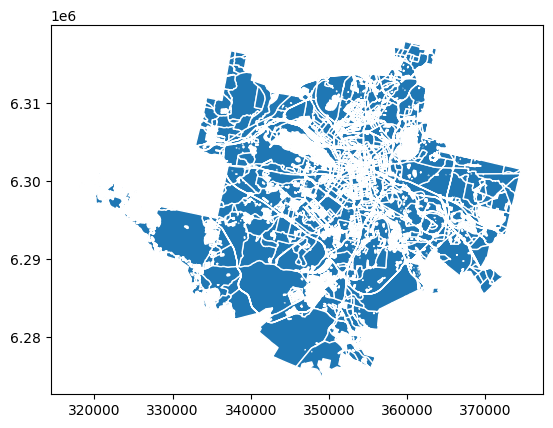

In [15]:
blocks_gdf.plot(linewidth=1, edgecolor='white')

### 1.3. Постообработка геометрий

In [16]:
from blocksnet.blocks.postprocessing import postprocess_urban_blocks

blocks_gdf = postprocess_urban_blocks(blocks_gdf)

In [17]:
# сохранение блоков
blocks_gdf.to_file('data/blocks_0.gpkg', driver='GPKG')

## 2. Назначение функциональных зон

In [1]:
import geopandas as gpd

In [3]:
import geopandas as gpd

blocks_gdf = gpd.read_file('data/blocks.gpkg')

In [16]:
blocks_gdf = blocks_gdf[['geometry']]

In [17]:
blocks_gdf.head()

,geometry
0,"MULTIPOLYGON (((352630.355 6299646.879, 352597..."
1,"MULTIPOLYGON (((355899.829 6295987.668, 355735..."
2,"MULTIPOLYGON (((345582.74 6277316.264, 345583...."
3,"MULTIPOLYGON (((346905.247 6278477.633, 346905..."
4,"MULTIPOLYGON (((346539.455 6277745.941, 346567..."


In [18]:
# Перевод MultiPolygon в Polygon
blocks_gdf = blocks_gdf.explode(index_parts=False)

# Если необходимо сбросить индекс после разделения:
blocks_gdf = blocks_gdf.reset_index(drop=True)


In [5]:
# загрузка функциональных зон
functional_zones_gdf = gpd.read_file('data/functional_zones.geojson')

In [6]:
functional_zones_gdf = functional_zones_gdf[['full_name', 'geometry']]

In [7]:
functional_zones_gdf.head()

,full_name,geometry
0,Жилые зоны,"POLYGON ((60.6907 56.8258, 60.6918 56.8259, 60..."
1,Жилые зоны,"POLYGON ((60.4745 56.8073, 60.4797 56.81, 60.4..."
2,Жилые зоны,"POLYGON ((60.2952 56.7619, 60.2958 56.7619, 60..."
3,Жилые зоны,"POLYGON ((60.5393 56.7837, 60.5412 56.7847, 60..."
4,Жилые зоны,"POLYGON ((60.5348 56.8095, 60.5361 56.8104, 60..."


In [13]:
functional_zones_gdf = functional_zones_gdf.to_crs(local_crs)
functional_zones_gdf = functional_zones_gdf.rename(columns={'full_name':'functional_zone'})
functional_zones_gdf = functional_zones_gdf.reset_index(drop=True)

In [15]:
functional_zones_gdf['functional_zone'].unique()

array(['Жилые зоны', 'Зона лесов',
       'Зона застройки индивидуальными жилыми домами', 'Зона акваторий',
       'Зона смешанной и общественно-деловой застройки',
       'Общественно-деловые зоны',
       'Зона застройки малоэтажными жилыми домами (до 4 этажей, включая мансардный)',
       'Зоны специального назначения',
       'Зона специализированной общественной застройки',
       'Производственные зоны, зоны инженерной и транспортной инфраструктур',
       'Зоны рекреационного назначения', 'Зона отдыха',
       'Зона режимных территорий', 'Зона транспортной инфраструктуры',
       'Лесопарковая зона', 'Зона сельскохозяйственных угодий',
       'Зона садоводческих, огороднических или дачных некоммерческих объединений граждан',
       'Производственная зона сельскохозяйственных предприятий',
       'Иные зоны сельскохозяйственного назначения',
       'Зона озелененных территорий общего пользования (лесопарки, парки, сады, скверы, бульвары, городские леса)',
       'Зона кладбищ'], 

In [90]:
from blocksnet.enums import LandUse

RULES = {
  'LandUse.RESIDENTIAL': LandUse.RESIDENTIAL,

  'LandUse.BUSINESS': LandUse.BUSINESS,

  'LandUse.RECREATION': LandUse.RECREATION,

  'LandUse.SPECIAL': LandUse.SPECIAL,

  'LandUse.TRANSPORT': LandUse.TRANSPORT,

  'LandUse.INDUSTRIAL': LandUse.INDUSTRIAL
}

In [14]:
from blocksnet.enums import LandUse

RULES = {
    # Жилые зоны
    'Жилые зоны': LandUse.RESIDENTIAL,
    'Зона застройки индивидуальными жилыми домами': LandUse.RESIDENTIAL,
    'Зона застройки малоэтажными жилыми домами (до 4 этажей, включая мансардный)': LandUse.RESIDENTIAL,
    
    # Общественно-деловые зоны
    'Общественно-деловые зоны': LandUse.BUSINESS,
    'Зона смешанной и общественно-деловой застройки': LandUse.BUSINESS,
    'Зона специализированной общественной застройки': LandUse.BUSINESS,
    
    # Рекреационные и природные зоны
    'Зоны рекреационного назначения': LandUse.RECREATION,
    'Зона отдыха': LandUse.RECREATION,
    'Лесопарковая зона': LandUse.RECREATION,
    'Зона озелененных территорий общего пользования (лесопарки, парки, сады, скверы, бульвары, городские леса)': LandUse.RECREATION,
    'Зона лесов': LandUse.RECREATION, # Можно вынести в отдельный LandUse.NATURAL, если требуется
    
    # Производственные и транспортные зоны
    'Производственные зоны, зоны инженерной и транспортной инфраструктур': LandUse.INDUSTRIAL,
    'Зона транспортной инфраструктуры': LandUse.TRANSPORT,
    'Производственная зона сельскохозяйственных предприятий': LandUse.INDUSTRIAL, # Либо AGRICULTURE, в зависимости от логики БД
    
    # Сельскохозяйственные зоны
    'Зона сельскохозяйственных угодий': LandUse.AGRICULTURE, # Если нет AGRICULTURE, можно отнести к SPECIAL
    'Зона садоводческих, огороднических или дачных некоммерческих объединений граждан': LandUse.AGRICULTURE, # Часто относят и к RESIDENTIAL
    'Иные зоны сельскохозяйственного назначения': LandUse.AGRICULTURE,
    
    # Зоны специального назначения
    'Зоны специального назначения': LandUse.SPECIAL,
    'Зона режимных территорий': LandUse.SPECIAL,
    'Зона кладбищ': LandUse.SPECIAL
}

In [19]:
from blocksnet.blocks.assignment import assign_land_use

land_use_gdf = assign_land_use(blocks_gdf, functional_zones_gdf, RULES)

2026-04-14 17:39:02.775 | WARNING  | blocksnet.blocks.assignment.land_use:_preprocess_functional_zones:17 - Functional zones not in rules: Зона акваторий


In [22]:
# сохранение блоков
land_use_gdf.to_file('data/blocks_LU.gpkg', driver='GPKG')

## 3. Агрегация параметров

### 3.1. Здания

Если здания уже есть, главное просто привести к следующему виду:

- `population : float`
- `footprint_area : float` -- building's base area
- `number_of_floors : float`
- `build_floor_area : float` -- sum area of each building floor
- `is_living : bool`
- `living_area : float` -- area defined for residents
- `non_living_area : float` -- area not defined to live in

In [24]:
# загрузка своих зданий

buildings_gdf = gpd.read_file('data/building.gpkg')
buildings_gdf = buildings_gdf.reset_index(drop=True).to_crs(local_crs)

In [25]:
buildings_geom_types=  ['Polygon', 'MultiPolygon']
buildings_gdf = buildings_gdf[buildings_gdf.geom_type.isin(buildings_geom_types)].copy()

In [26]:
for gdf in [buildings_gdf, blocks_gdf]:
  gdf.to_crs(local_crs, inplace=True)
  gdf.reset_index(drop=True, inplace=True)

#### Предобработка зданий

In [27]:
buildings_gdf.head()

,footprint_area,number_of_floors,is_living,living_area,non_living_area,build_floor_area,population,geometry
0,71.269472,1,False,0.0,71.269472,71.269472,0,"MULTIPOLYGON Z (((368735.612 6287398.028 0, 36..."
1,68.439782,1,False,0.0,68.439782,68.439782,0,"MULTIPOLYGON Z (((368763.165 6287414.821 0, 36..."
2,255.736269,1,False,0.0,255.736269,255.736269,0,"MULTIPOLYGON Z (((368743.417 6287351.079 0, 36..."
3,651.614460,1,False,0.0,651.614460,651.614460,0,"MULTIPOLYGON Z (((349797.105 6301710.037 0, 34..."
4,68.277800,1,False,0.0,68.277800,68.277800,0,"MULTIPOLYGON Z (((352249.35 6306675.901 0, 352..."


In [ ]:
# Перевод MultiPolygon в Polygon
buildings_gdf = buildings_gdf.explode(index_parts=False)

# Если необходимо сбросить индекс после разделения:
buildings_gdf = buildings_gdf.reset_index(drop=True)

In [29]:
buildings_gdf.columns

Index(['footprint_area', 'number_of_floors', 'is_living', 'living_area',
       'non_living_area', 'build_floor_area', 'population', 'geometry'],
      dtype='object')

In [27]:
import pandas as pd
import numpy as np

buildings_gdf['population'] = np.nan

# 1. Переименовываем столбцы
buildings_gdf = buildings_gdf.rename(columns={
    'isApartmentBuilding': 'is_living',
    'livingQuarters': 'living_area',
    'r_floors': 'number_of_floors',
    'Area': 'footprint_area'
})

# 2. Обработка этажности:
# Берем значения по модулю (отрицательные становятся положительными)
buildings_gdf['number_of_floors'] = buildings_gdf['number_of_floors'].abs()

# Заменяем нулевые этажи на 1
buildings_gdf['number_of_floors'] = buildings_gdf['number_of_floors'].replace(0, 1)

# 3. Считаем build_floor_area 
# (теперь здесь точно не будет минусов из-за этажей)
buildings_gdf['build_floor_area'] = buildings_gdf['number_of_floors'] * buildings_gdf['footprint_area']

# 4. Считаем non_living_area
buildings_gdf['non_living_area'] = np.where(
    buildings_gdf['is_living'] == 1,
    buildings_gdf['build_floor_area'] - buildings_gdf['living_area'],
    buildings_gdf['build_floor_area']
)

# ВАЖНО: Оставляем отсечение минусов для non_living_area.
# Ошибка валидации все равно может выскочить, если в "грязных" исходных данных 
# указанная жилая площадь (living_area) оказалась физически больше общей (build_floor_area).
buildings_gdf['non_living_area'] = buildings_gdf['non_living_area'].clip(lower=0)

# 5. Применяем схему типов
schema = {
    'population': float,
    'footprint_area': float,
    'number_of_floors': float,
    'build_floor_area': float,
    'is_living': bool, 
    'living_area': float,
    'non_living_area': float
}
buildings_gdf = buildings_gdf.astype(schema)

#### Агрегация

In [28]:
from blocksnet.preprocessing.imputing import impute_buildings

imp_gdf = impute_buildings(buildings_gdf, default_living_demand=35)

In [29]:
imp_gdf.population.sum()

np.float64(1514792.0)

In [30]:
from blocksnet.blocks.aggregation import aggregate_objects

agg_gdf, bad_gdf = aggregate_objects(blocks_gdf, buildings_gdf)

2026-04-14 17:41:09.290 | INFO     | blocksnet.blocks.aggregation.core:_preprocess_input:12 - Preprocessing input
2026-04-14 17:41:09.463 | INFO     | blocksnet.blocks.aggregation.core:aggregate_objects:41 - Aggregating objects


Объединение нескольких слоев с одним индексом но разными столбцами:

- `blocks_gdf`
- `land_use_gdf`
- `agg_gdf`

In [33]:
blocks_gdf = blocks_gdf[['geometry']].copy()
rights = [land_use_gdf, agg_gdf]

for right in rights:
  blocks_gdf = blocks_gdf.join(right.drop(columns=['geometry']))

blocks_gdf.columns

Index(['geometry', 'residential', 'business', 'recreation', 'industrial',
       'transport', 'special', 'agriculture', 'land_use', 'share',
       'footprint_area', 'number_of_floors', 'is_living', 'living_area',
       'non_living_area', 'build_floor_area', 'population', 'count'],
      dtype='object')

In [34]:
blocks_gdf.head()

,geometry,residential,business,recreation,industrial,transport,special,agriculture,land_use,share,footprint_area,number_of_floors,is_living,living_area,non_living_area,build_floor_area,population,count
0,"POLYGON ((352630.355 6299646.879, 352597.291 6...",0.922104,0.001231,0.058449,0.0,0.020253,0.0,0.000000,LandUse.RESIDENTIAL,0.922104,93861.769834,537.0,67.0,368329.588244,158499.825318,526829.413562,9956.0,113.0
1,"POLYGON ((355899.829 6295987.668, 355735.891 6...",0.985947,0.000000,0.000000,0.0,0.014053,0.0,0.000000,LandUse.RESIDENTIAL,0.985947,3754.220153,30.0,15.0,1514.799215,2239.420938,3754.220153,38.0,30.0
2,"POLYGON ((345582.74 6277316.264, 345583.467 62...",0.000000,0.000000,0.202280,0.0,0.000000,0.0,0.797720,LandUse.AGRICULTURE,0.797720,0.000000,0.0,0.0,0.000000,0.000000,0.000000,0.0,0.0
3,"POLYGON ((346905.247 6278477.633, 346905.257 6...",0.000000,0.000000,0.055102,0.0,0.000000,0.0,0.944898,LandUse.AGRICULTURE,0.944898,0.000000,0.0,0.0,0.000000,0.000000,0.000000,0.0,0.0
4,"POLYGON ((346539.455 6277745.941, 346567.51 62...",0.000000,0.000000,0.068394,0.0,0.000000,0.0,0.931606,LandUse.AGRICULTURE,0.931606,0.000000,0.0,0.0,0.000000,0.000000,0.000000,0.0,0.0


In [35]:
blocks_gdf.to_file('data/blocks_agg_buildings.gpkg', driver='GPKG')

Визуализация параметров кварталов

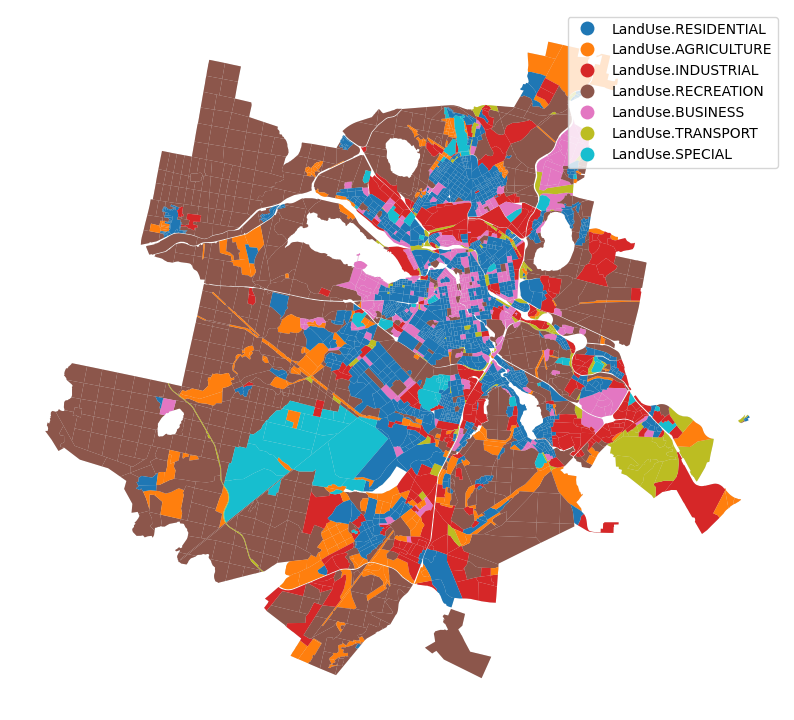

In [36]:
ax = left.plot(color='#ddd', figsize=(10,10))
left.plot(column='land_use', legend=True, ax=ax).set_axis_off()

Просмотр типов сервисов, которые можно добавить в кварталы

In [53]:
from blocksnet.config import service_types_config

service_types_config.service_types

,name_ru,demand,accessibility
school,школа,120,15
kindergarten,детский сад,61,7
hospital,больница,9,60
polyclinic,поликлиника,13,15
pitch,спортивная площадка,10,60
...,...,...,...
construction,объекты строительной промышленности,1,60
woodworking,объекты деревообрабатывающей и целлюлозно-бума...,1,60
electronics_industry,объекты электроники и высоких технологий,1,60
agricultural_services,объекты сельскохозяйственных сервисов,1,60


### 3.2. Сервисы

In [2]:
import geopandas as gpd

In [27]:
left = gpd.read_file("data/blocks_agg.geojson")

In [37]:
import os
import pandas as pd
import geopandas as gpd
from blocksnet.preprocessing.imputing import impute_services
from blocksnet.blocks.aggregation import aggregate_objects

service_directory = 'data/platform'

# --- ШАГ 1: Сбор и группировка ---
raw_services_buffer = {}

for filename in os.listdir(service_directory):
    if filename.endswith('.geojson'):
        try:
            # Извлекаем имя файла без расширения .geojson в качестве имени сервиса
            service_type_name = os.path.splitext(filename)[0]

            filepath = os.path.join(service_directory, filename)
            # Примечание: local_crs должен быть определен до запуска этого кода
            gdf_raw = gpd.read_file(filepath).to_crs(local_crs)

            # Удаляем пустые геометрии
            initial_len = len(gdf_raw)
            gdf_raw = gdf_raw[gdf_raw.geometry.notna() & ~gdf_raw.geometry.is_empty]
            if len(gdf_raw) < initial_len:
                print(f"⚠️ В файле {filename} удалено {initial_len - len(gdf_raw)} объектов без геометрии")

            if not gdf_raw.empty:
                if service_type_name not in raw_services_buffer:
                    raw_services_buffer[service_type_name] = []
                raw_services_buffer[service_type_name].append(gdf_raw)
        except Exception as e:
            print(f"Skipping {filename}: {e}")

# --- ШАГ 2: Агрегация ---
gdfs = {}

print("\nАгрегация данных...")
for service_name, gdf_list in raw_services_buffer.items():
    try:
        # 1. Объединяем списки геодатафреймов для одного типа (если вдруг файлов с одинаковым названием было несколько)
        full_service_gdf = pd.concat(gdf_list, ignore_index=True)

        # 2. Попытка восстановить атрибуты (capacity)
        # Если тип не найден в blocksnet, ставим заглушку
        try:
            full_service_gdf = impute_services(full_service_gdf, service_name)
        except Exception as e:
            # Ошибка "not found in service types config" попадет сюда
            print(f"  ℹ️ Тип '{service_name}' не найден в конфиге blocksnet. Пропускаем расчет емкости.")
            # Добавляем фиктивную колонку capacity, чтобы aggregate_objects не упал
            if 'capacity' not in full_service_gdf.columns:
                full_service_gdf['capacity'] = 0

        # 3. Агрегируем (Примечание: left должен быть определен до запуска кода)
        aggregated_gdf, _ = aggregate_objects(left, full_service_gdf)

        gdfs[service_name] = aggregated_gdf
        print(f"  ✅ {service_name} обработан")

    except Exception as e:
        print(f"❌ Критическая ошибка с {service_name}: {e}")

# --- ШАГ 3: Джойн ---
blocks_gdf = left.copy()

for st, gdf in gdfs.items():
    if 'geometry' in gdf.columns:
        gdf = gdf.drop(columns=['geometry'])

    # Добавляем суффикс с именем файла ко всем колонкам
    columns = {c: f'{c}_{st}' for c in gdf.columns}
    gdf = gdf.rename(columns=columns)
    blocks_gdf = blocks_gdf.join(gdf)

print("\nВсе готово!")
display(blocks_gdf.head())

2026-04-14 17:42:30.208 | INFO     | blocksnet.blocks.aggregation.core:_preprocess_input:12 - Preprocessing input
2026-04-14 17:42:30.209 | INFO     | blocksnet.blocks.aggregation.core:aggregate_objects:41 - Aggregating objects
2026-04-14 17:42:30.227 | INFO     | blocksnet.blocks.aggregation.core:_preprocess_input:12 - Preprocessing input
2026-04-14 17:42:30.230 | INFO     | blocksnet.blocks.aggregation.core:aggregate_objects:41 - Aggregating objects
2026-04-14 17:42:30.251 | INFO     | blocksnet.blocks.aggregation.core:_preprocess_input:12 - Preprocessing input
2026-04-14 17:42:30.253 | INFO     | blocksnet.blocks.aggregation.core:aggregate_objects:41 - Aggregating objects
2026-04-14 17:42:30.275 | INFO     | blocksnet.blocks.aggregation.core:_preprocess_input:12 - Preprocessing input
2026-04-14 17:42:30.278 | INFO     | blocksnet.blocks.aggregation.core:aggregate_objects:41 - Aggregating objects
2026-04-14 17:42:30.304 | INFO     | blocksnet.blocks.aggregation.core:_preprocess_input


Агрегация данных...
  ✅ animal_shelter обработан
  ✅ bakery обработан
  ✅ bank обработан
  ✅ bar обработан
  ℹ️ Тип 'beauty' не найден в конфиге blocksnet. Пропускаем расчет емкости.
  ✅ beauty обработан
  ℹ️ Тип 'books' не найден в конфиге blocksnet. Пропускаем расчет емкости.
  ✅ books обработан
  ✅ bus_station обработан


2026-04-14 17:42:30.403 | INFO     | blocksnet.blocks.aggregation.core:_preprocess_input:12 - Preprocessing input
2026-04-14 17:42:30.406 | INFO     | blocksnet.blocks.aggregation.core:aggregate_objects:41 - Aggregating objects
2026-04-14 17:42:30.427 | INFO     | blocksnet.blocks.aggregation.core:_preprocess_input:12 - Preprocessing input
2026-04-14 17:42:30.429 | INFO     | blocksnet.blocks.aggregation.core:aggregate_objects:41 - Aggregating objects
2026-04-14 17:42:30.449 | INFO     | blocksnet.blocks.aggregation.core:_preprocess_input:12 - Preprocessing input
2026-04-14 17:42:30.450 | INFO     | blocksnet.blocks.aggregation.core:aggregate_objects:41 - Aggregating objects
2026-04-14 17:42:30.469 | INFO     | blocksnet.blocks.aggregation.core:_preprocess_input:12 - Preprocessing input
2026-04-14 17:42:30.471 | INFO     | blocksnet.blocks.aggregation.core:aggregate_objects:41 - Aggregating objects
2026-04-14 17:42:30.491 | INFO     | blocksnet.blocks.aggregation.core:_preprocess_input

  ✅ bus_stop обработан
  ✅ cafe обработан
  ✅ cemetery обработан
  ✅ cinema обработан
  ℹ️ Тип 'clothes' не найден в конфиге blocksnet. Пропускаем расчет емкости.
  ✅ clothes обработан
  ✅ college обработан
  ✅ convenience обработан
  ✅ crematorium обработан
  ℹ️ Тип 'dentist' не найден в конфиге blocksnet. Пропускаем расчет емкости.
  ✅ dentist обработан


2026-04-14 17:42:30.580 | INFO     | blocksnet.blocks.aggregation.core:aggregate_objects:41 - Aggregating objects
2026-04-14 17:42:30.601 | INFO     | blocksnet.blocks.aggregation.core:_preprocess_input:12 - Preprocessing input
2026-04-14 17:42:30.604 | INFO     | blocksnet.blocks.aggregation.core:aggregate_objects:41 - Aggregating objects
2026-04-14 17:42:30.626 | INFO     | blocksnet.blocks.aggregation.core:_preprocess_input:12 - Preprocessing input
2026-04-14 17:42:30.628 | INFO     | blocksnet.blocks.aggregation.core:aggregate_objects:41 - Aggregating objects
2026-04-14 17:42:30.649 | INFO     | blocksnet.blocks.aggregation.core:_preprocess_input:12 - Preprocessing input
2026-04-14 17:42:30.651 | INFO     | blocksnet.blocks.aggregation.core:aggregate_objects:41 - Aggregating objects
2026-04-14 17:42:30.672 | INFO     | blocksnet.blocks.aggregation.core:_preprocess_input:12 - Preprocessing input
2026-04-14 17:42:30.674 | INFO     | blocksnet.blocks.aggregation.core:aggregate_objects

...

2026-04-14 17:42:31.365 | INFO     | blocksnet.blocks.aggregation.core:aggregate_objects:41 - Aggregating objects
2026-04-14 17:42:31.385 | INFO     | blocksnet.blocks.aggregation.core:_preprocess_input:12 - Preprocessing input
2026-04-14 17:42:31.386 | INFO     | blocksnet.blocks.aggregation.core:aggregate_objects:41 - Aggregating objects
2026-04-14 17:42:31.409 | INFO     | blocksnet.blocks.aggregation.core:_preprocess_input:12 - Preprocessing input
2026-04-14 17:42:31.410 | INFO     | blocksnet.blocks.aggregation.core:aggregate_objects:41 - Aggregating objects
2026-04-14 17:42:31.431 | INFO     | blocksnet.blocks.aggregation.core:_preprocess_input:12 - Preprocessing input
2026-04-14 17:42:31.432 | INFO     | blocksnet.blocks.aggregation.core:aggregate_objects:41 - Aggregating objects
2026-04-14 17:42:31.452 | INFO     | blocksnet.blocks.aggregation.core:_preprocess_input:12 - Preprocessing input
2026-04-14 17:42:31.454 | INFO     | blocksnet.blocks.aggregation.core:aggregate_objects

  ✅ restaurant обработан
  ✅ school обработан
  ℹ️ Тип 'shop_pets' не найден в конфиге blocksnet. Пропускаем расчет емкости.
  ✅ shop_pets обработан
  ℹ️ Тип 'shop_sport' не найден в конфиге blocksnet. Пропускаем расчет емкости.
  ✅ shop_sport обработан
  ℹ️ Тип 'sports_centre' не найден в конфиге blocksnet. Пропускаем расчет емкости.
  ✅ sports_centre обработан
  ✅ stadium обработан
  ✅ substation обработан
  ℹ️ Тип 'subway' не найден в конфиге blocksnet. Пропускаем расчет емкости.
  ✅ subway обработан
  ✅ supermarket обработан


2026-04-14 17:42:31.565 | INFO     | blocksnet.blocks.aggregation.core:_preprocess_input:12 - Preprocessing input
2026-04-14 17:42:31.567 | INFO     | blocksnet.blocks.aggregation.core:aggregate_objects:41 - Aggregating objects
2026-04-14 17:42:31.589 | INFO     | blocksnet.blocks.aggregation.core:_preprocess_input:12 - Preprocessing input
2026-04-14 17:42:31.590 | INFO     | blocksnet.blocks.aggregation.core:aggregate_objects:41 - Aggregating objects
2026-04-14 17:42:31.613 | INFO     | blocksnet.blocks.aggregation.core:_preprocess_input:12 - Preprocessing input
2026-04-14 17:42:31.615 | INFO     | blocksnet.blocks.aggregation.core:aggregate_objects:41 - Aggregating objects
2026-04-14 17:42:31.635 | INFO     | blocksnet.blocks.aggregation.core:_preprocess_input:12 - Preprocessing input
2026-04-14 17:42:31.637 | INFO     | blocksnet.blocks.aggregation.core:aggregate_objects:41 - Aggregating objects
2026-04-14 17:42:31.656 | INFO     | blocksnet.blocks.aggregation.core:_preprocess_input

  ✅ swimming_pool обработан
  ℹ️ Тип 'theme_park' не найден в конфиге blocksnet. Пропускаем расчет емкости.
  ✅ theme_park обработан
  ✅ train_building обработан
  ✅ train_station обработан
  ✅ university обработан
  ✅ veterinary обработан
  ✅ wastewater_plant обработан

Все готово!


,geometry,residential,business,recreation,industrial,transport,special,agriculture,land_use,share,...,capacity_train_building,count_train_building,capacity_train_station,count_train_station,capacity_university,count_university,capacity_veterinary,count_veterinary,capacity_wastewater_plant,count_wastewater_plant
0,"POLYGON ((352630.355 6299646.879, 352597.291 6...",0.922104,0.001231,0.058449,0.0,0.020253,0.0,0.000000,LandUse.RESIDENTIAL,0.922104,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1,"POLYGON ((355899.829 6295987.668, 355735.891 6...",0.985947,0.000000,0.000000,0.0,0.014053,0.0,0.000000,LandUse.RESIDENTIAL,0.985947,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,"POLYGON ((345582.74 6277316.264, 345583.467 62...",0.000000,0.000000,0.202280,0.0,0.000000,0.0,0.797720,LandUse.AGRICULTURE,0.797720,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3,"POLYGON ((346905.247 6278477.633, 346905.257 6...",0.000000,0.000000,0.055102,0.0,0.000000,0.0,0.944898,LandUse.AGRICULTURE,0.944898,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4,"POLYGON ((346539.455 6277745.941, 346567.51 62...",0.000000,0.000000,0.068394,0.0,0.000000,0.0,0.931606,LandUse.AGRICULTURE,0.931606,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


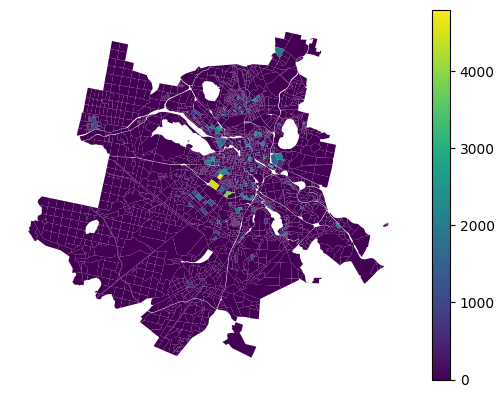

In [38]:
blocks_gdf.plot('capacity_school', legend=True).set_axis_off()

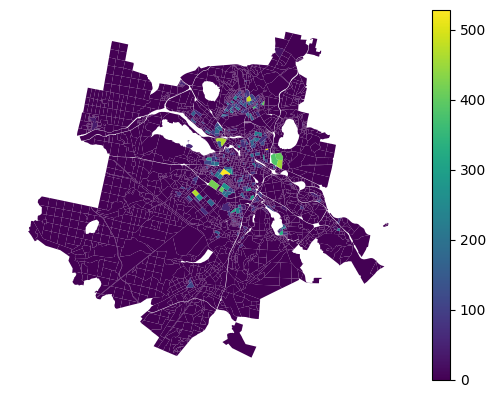

In [39]:
blocks_gdf.plot('capacity_kindergarten', legend=True).set_axis_off()

In [42]:
blocks_gdf.to_file('data/blocks_with_services.gpkg', driver='GPKG')

In [41]:
blocks_gdf['block_id'] = blocks_gdf.index

In [58]:
import geopandas as gpd

blocks_gdf = gpd.read_file('data/blocks_with_services_1500.geojson')

DataSourceError: data/blocks_with_services_1500.geojson: No such file or directory

In [3]:
blocks_gdf.head()

,residential,business,recreation,industrial,transport,special,agriculture,land_use,share,is_living,...,count_train_building,capacity_train_station,count_train_station,capacity_university,count_university,capacity_veterinary,count_veterinary,capacity_wastewater_plant,count_wastewater_plant,geometry
0,0.100648,0.01854,0.531974,0.167724,0.054758,0.009663,0.116237,LandUse.RECREATION,0.531974,1091.0,...,0.0,200.0,1.0,0.0,0.0,17.0,1.0,0.0,0.0,"POLYGON ((6754528.38 7710519.72, 6754638.959 7..."
1,0.100648,0.01854,0.531974,0.167724,0.054758,0.009663,0.116237,LandUse.RECREATION,0.531974,1091.0,...,0.0,200.0,1.0,0.0,0.0,17.0,1.0,0.0,0.0,"POLYGON ((6754528.38 7710519.72, 6754638.959 7..."
2,0.000000,0.00000,0.118480,0.000000,0.000000,0.000000,0.000000,LandUse.RECREATION,0.118480,6.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,"POLYGON ((6699651.159 7714369.607, 6699761.239..."
3,0.000000,0.00000,0.118480,0.000000,0.000000,0.000000,0.000000,LandUse.RECREATION,0.118480,6.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,"POLYGON ((6699651.159 7714369.607, 6699761.239..."
4,0.000000,0.00000,0.999386,0.000000,0.000000,0.000000,0.000000,LandUse.RECREATION,0.999386,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,"POLYGON ((6709980.362 7714311.16, 6709727.381 ..."


## 4. Построение матрицы доступности и оценка кварталов по ней

### 4.1 Транспортный граф территории

Получение графа по территории

In [ ]:
from blocksnet.relations import get_accessibility_graph

graph = get_accessibility_graph(boundaries_gdf, 'drive') # можно получить и другой тип графа,
                                                         # изменив graph_type на 'walk' или 'intermodal'

Построение матрицы доступности

In [ ]:
from blocksnet.relations import calculate_accessibility_matrix

acc_mx = calculate_accessibility_matrix(left, graph)

Сохранение матрицы в файл:

In [ ]:
acc_mx.to_pickle('matrix_before.pickle')

In [ ]:
matrix = pd.read_pickle('/content/matrix_before.pickle')

Утилз для иллюстраций:

In [ ]:
import geopandas as gpd

def plot_accessibility(accessibility_df : pd.DataFrame, method):
    gdf = blocks_gdf[['geometry']].join(accessibility_df)
    column = [c for c in gdf.columns if 'accessibility' in c][0]
    ax = gdf.plot(column=column, legend=True)
    ax.set_axis_off()
    ax.set_title(method.__name__)

Медианная доступность/транспортная связанность по кварталам

In [ ]:
from blocksnet.analysis.network import median_accessibility

med_acc_df = median_accessibility(acc_mx)
med_acc_df.head()

/usr/local/lib/python3.12/dist-packages/pandas/io/formats/format.py:1458: RuntimeWarning: overflow encountered in cast
  has_large_values = (abs_vals > 1e6).any()


,median_accessibility
0,15.250000
1,15.742188
2,9.250000
3,10.531250
4,8.070312


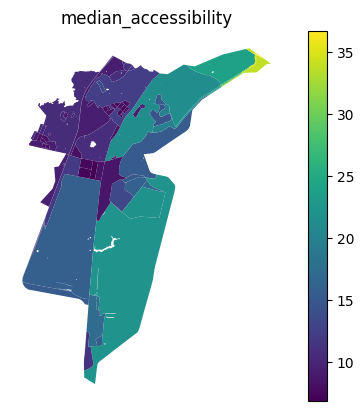

In [ ]:
plot_accessibility(med_acc_df, median_accessibility)

In [ ]:
gdf = blocks_gdf[['geometry']].join(med_acc_df)
gdf['median_accessibility'] = gdf['median_accessibility'].astype('float64')
gdf.to_file('median_accessibility_before.geojson', driver='GeoJSON')

Средняя доступность

In [ ]:
from blocksnet.analysis.network import mean_accessibility

mean_acc_df = mean_accessibility(acc_mx)
mean_acc_df.head()

/usr/local/lib/python3.12/dist-packages/pandas/io/formats/format.py:1458: RuntimeWarning: overflow encountered in cast
  has_large_values = (abs_vals > 1e6).any()


,mean_accessibility
0,9.593750
1,10.101562
2,8.234375
3,10.117188
4,9.539062


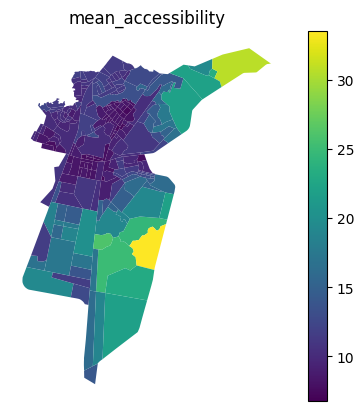

In [ ]:
plot_accessibility(mean_acc_df, mean_accessibility)

Максимальное значение доступности для каждого квартала

In [ ]:
from blocksnet.analysis.network import max_accessibility

max_acc_df = max_accessibility(acc_mx)
max_acc_df.head()

/usr/local/lib/python3.12/dist-packages/pandas/io/formats/format.py:1458: RuntimeWarning: overflow encountered in cast
  has_large_values = (abs_vals > 1e6).any()


,max_accessibility
0,32.062500
1,32.562500
2,30.546875
3,32.562500
4,31.968750


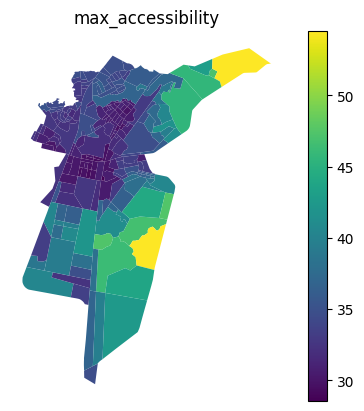

In [ ]:
plot_accessibility(max_acc_df, max_accessibility)

"Взвешенная" доступность по площади кварталов

In [ ]:
left['site_area'] = left.area

In [ ]:
from blocksnet.analysis.network import area_accessibility

area_acc_df = area_accessibility(acc_mx[[84,236]], left)
area_acc_df.head()

,area_accessibility
0,7.158420
1,7.658420
2,5.646701
3,7.674045
4,7.080295


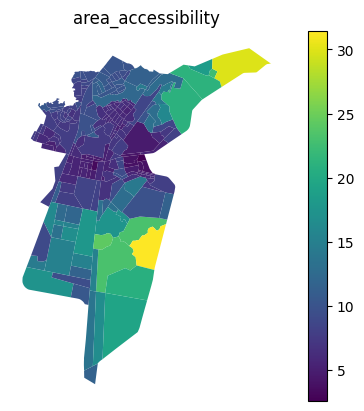

In [ ]:
plot_accessibility(area_acc_df, area_accessibility)

In [ ]:
gdf = blocks_gdf[['geometry']].join(area_acc_df)
gdf['area_accessibility'] = gdf['area_accessibility'].astype('float64')
gdf.to_file('area_accessibility.geojson', driver='GeoJSON')

Доступность от выбранного квартала

In [ ]:
from blocksnet.analysis.network import relative_accessibility

block_id = 236
rel_acc_df = relative_accessibility(acc_mx, block_id)
rel_acc_df.head()

/usr/local/lib/python3.12/dist-packages/pandas/io/formats/format.py:1458: RuntimeWarning: overflow encountered in cast
  has_large_values = (abs_vals > 1e6).any()


,relative_accessibility
0,9.250000
1,9.750000
2,7.738281
3,9.765625
4,9.171875


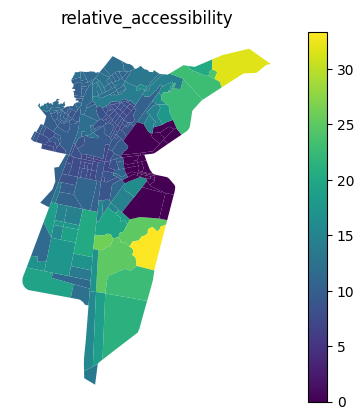

In [ ]:
plot_accessibility(rel_acc_df, relative_accessibility)

In [ ]:
from blocksnet.enums import LandUse
from blocksnet.analysis.network import land_use_accessibility

lu_acc_df = land_use_accessibility(acc_mx, left, LandUse.BUSINESS, out=True)
lu_acc_df.head()

/usr/local/lib/python3.12/dist-packages/pandas/io/formats/format.py:1458: RuntimeWarning: overflow encountered in cast
  has_large_values = (abs_vals > 1e6).any()


,land_use_accessibility
0,5.773438
1,6.273438
2,4.671875
3,6.289062
4,5.699219


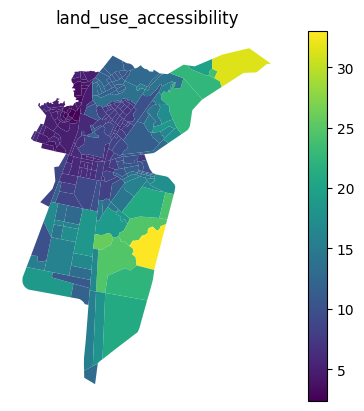

In [ ]:
plot_accessibility(lu_acc_df, land_use_accessibility)

### Домашнее задание на 22.10.2025:

Каждой команде необходимо выполнить
следующее задание:
- Подготовить слой городских кварталов
исследуемой территории с контекстом, если это не было сделано на курсе по сбору и обработке данных.
- Подготовить слой функциональных или
территориальных зон и назначить кварталам
соответствующие функции.
- Подготовить слой городских зданий,
восполнить недостающие параметры и
агрегировать в рамках городских кварталов.
- Подготовить слои необходимых городских
сервисов, восполнить недостающие
параметры и агрегировать в рамках
городских кварталов.
- Объединить полученные результаты в
единый слой кварталов.
- Посчитать матрицу доступности на дорожном графе по кварталам исследуемой территории с контекстом. Матрицу сохранить в формате .pickle

Слой должен быть в соответствующей CRS.
Необходимые атрибуты представлены в презентации.

К 29.10.25:
1. На ваших моделях (как есть) прогнать желаемые метрики из blocksnet.analysis (competitive_provision, services_centrality, ...). Обеспеченность попробовать для разных типов сервисов.
2. Попробовать сделать выводы исходя из метрик: может быть уже существует какой-то дефицит или определенный потенциал?
Опционально. Сценарная история: поменять ваши выбранные кварталы, прогнать метрики заново и сделать выводы: всё ли ок с учетом вашего проекта.

## competitive_provision

In [ ]:
from blocksnet.analysis.provision import competitive_provision

In [ ]:
service_type = 'school'

df = blocks_with_services_gdf[['population', f'capacity_{service_type}']].rename(columns={f'capacity_{service_type}':'capacity'})

In [ ]:
from blocksnet.config import service_types_config

service_type = 'school'
_, demand, accessibility = service_types_config[service_type].values()
demand, accessibility

(120, 15)

In [ ]:
prov_df_before, _ = competitive_provision(df, acc_mx, accessibility, demand)

2025-11-09 06:28:07.723 | INFO     | blocksnet.analysis.provision.competivive.core:_initialize_provision_df:29 - Initializing provision DataFrame
2025-11-09 06:28:07.724 | WARNING  | blocksnet.analysis.provision.competivive.core:_initialize_provision_df:33 - No demand in columns. Imputing using population column and demand parameter
2025-11-09 06:28:07.739 | INFO     | blocksnet.analysis.provision.competivive.core:_supply_self:56 - Supplying blocks with own capacities
2025-11-09 06:28:07.742 | INFO     | blocksnet.analysis.provision.competivive.core:competitive_provision:180 - Setting and solving LP problems until max depth or break condition reached
2025-11-09 06:28:07.799 | SUCCESS  | blocksnet.analysis.provision.competivive.core:competitive_provision:193 - Provision assessment finished


<Axes: >

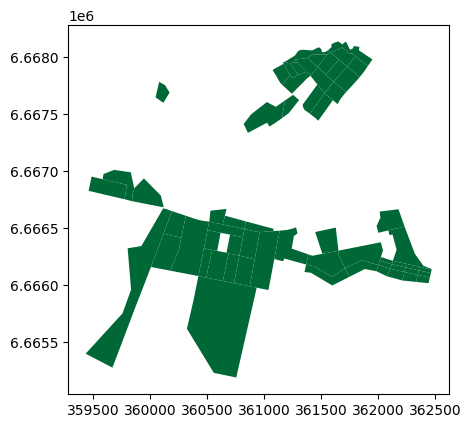

In [ ]:
blocks_gdf[['geometry']].join(prov_df_before).plot('provision_strong', vmin=0, vmax=1, cmap='RdYlGn')

In [ ]:
gdf = blocks_gdf[['geometry']].join(prov_df_before)
gdf.to_file('competitive_provision_school_before.geojson', driver='GeoJSON')

In [ ]:
df_after = df.copy()
df_after.population = df_after.population * 2

In [ ]:
prov_df_before, _ = competitive_provision(df_after, acc_mx, accessibility, demand)

2025-10-29 14:34:02.086 | INFO     | blocksnet.analysis.provision.competivive.core:_initialize_provision_df:29 - Initializing provision DataFrame
2025-10-29 14:34:02.088 | WARNING  | blocksnet.analysis.provision.competivive.core:_initialize_provision_df:33 - No demand in columns. Imputing using population column and demand parameter
2025-10-29 14:34:02.112 | INFO     | blocksnet.analysis.provision.competivive.core:_supply_self:56 - Supplying blocks with own capacities
2025-10-29 14:34:02.121 | INFO     | blocksnet.analysis.provision.competivive.core:competitive_provision:180 - Setting and solving LP problems until max depth or break condition reached
2025-10-29 14:34:02.190 | SUCCESS  | blocksnet.analysis.provision.competivive.core:competitive_provision:193 - Provision assessment finished


<Axes: >

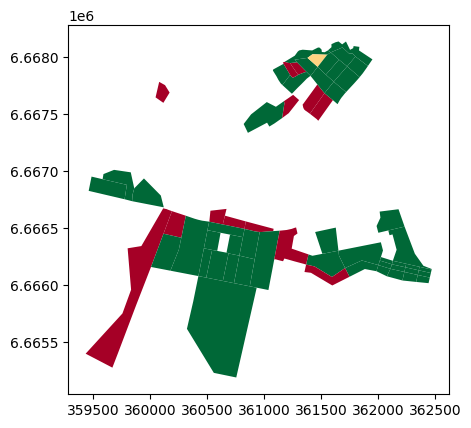

In [ ]:
blocks_gdf[['geometry']].join(prov_df_before).plot('provision_strong', vmin=0, vmax=1, cmap='RdYlGn')

In [ ]:
#сохранение school
blocks_gdf[['geometry']].join(prov_df_before).to_file('school.geojson', driver='GeoJSON')

In [ ]:
service_type = 'kindergarten'
_, demand, accessibility = service_types_config[service_type].values()
demand, accessibility

(61, 7)

In [ ]:
prov_df_before, _ = competitive_provision(df, acc_mx, accessibility, demand)

2025-11-09 06:29:55.652 | INFO     | blocksnet.analysis.provision.competivive.core:_initialize_provision_df:29 - Initializing provision DataFrame
2025-11-09 06:29:55.653 | WARNING  | blocksnet.analysis.provision.competivive.core:_initialize_provision_df:33 - No demand in columns. Imputing using population column and demand parameter
2025-11-09 06:29:55.667 | INFO     | blocksnet.analysis.provision.competivive.core:_supply_self:56 - Supplying blocks with own capacities
2025-11-09 06:29:55.672 | INFO     | blocksnet.analysis.provision.competivive.core:competitive_provision:180 - Setting and solving LP problems until max depth or break condition reached
2025-11-09 06:29:55.711 | SUCCESS  | blocksnet.analysis.provision.competivive.core:competitive_provision:193 - Provision assessment finished


<Axes: >

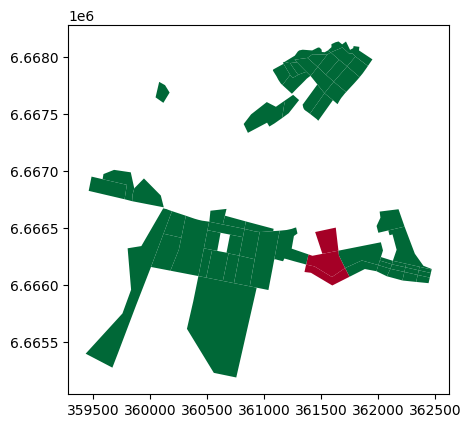

In [ ]:
blocks_gdf[['geometry']].join(prov_df_before).plot('provision_strong', vmin=0, vmax=1, cmap='RdYlGn')

In [ ]:
#сохранение kindergarten
blocks_gdf[['geometry']].join(prov_df_before).to_file('provision_kindergarten.geojson', driver='GeoJSON')

In [ ]:
df_after = df.copy()
df_after.population = df_after.population * 2

In [ ]:
prov_df_before, _ = competitive_provision(df_after, acc_mx, accessibility, demand)

2025-10-29 14:34:29.909 | INFO     | blocksnet.analysis.provision.competivive.core:_initialize_provision_df:29 - Initializing provision DataFrame
2025-10-29 14:34:29.911 | WARNING  | blocksnet.analysis.provision.competivive.core:_initialize_provision_df:33 - No demand in columns. Imputing using population column and demand parameter
2025-10-29 14:34:29.930 | INFO     | blocksnet.analysis.provision.competivive.core:_supply_self:56 - Supplying blocks with own capacities
2025-10-29 14:34:29.938 | INFO     | blocksnet.analysis.provision.competivive.core:competitive_provision:180 - Setting and solving LP problems until max depth or break condition reached
2025-10-29 14:34:30.015 | SUCCESS  | blocksnet.analysis.provision.competivive.core:competitive_provision:193 - Provision assessment finished


<Axes: >

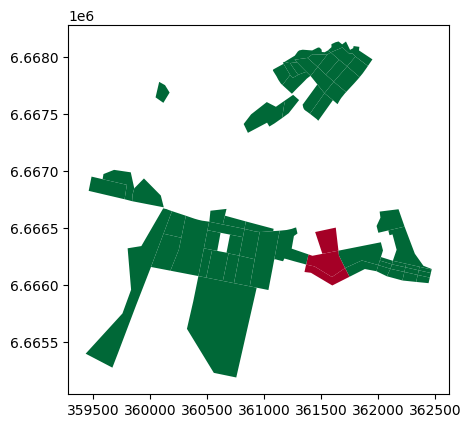

In [ ]:
blocks_gdf[['geometry']].join(prov_df_before).plot('provision_strong', vmin=0, vmax=1, cmap='RdYlGn')

## services_centrality

In [ ]:
# Проверим CRS
print(blocks_with_services_gdf.crs)

EPSG:32636


In [ ]:
# Рассчитываем площадь (в квадратных метрах)
blocks_with_services_gdf["site_area"] = blocks_with_services_gdf.geometry.area

# Проверяем результат
print(blocks_with_services_gdf[["site_area"]].head())

      site_area
0  24553.002149
1  12482.897714
2  40827.040875
3  19601.791821
4  21021.581981


In [ ]:
from blocksnet.analysis.centrality import services_centrality

centrality_df = services_centrality(acc_mx, blocks_with_services_gdf)
centrality_df.head()

2025-11-09 06:34:03.993 | INFO     | blocksnet.analysis.diversity.shannon.core:shannon_diversity:23 - Calculating Shannon diversity index
100%|██████████| 239/239 [00:00<00:00, 2026.05it/s]


,connectivity,diversity,density,services_centrality
0,0.104235,0.0,0.000000,0.210355
1,0.098995,0.0,0.000000,0.195537
2,0.121442,0.0,0.000024,0.283108
3,0.098842,0.0,0.000051,0.245280
4,0.104832,0.0,0.000000,0.212045


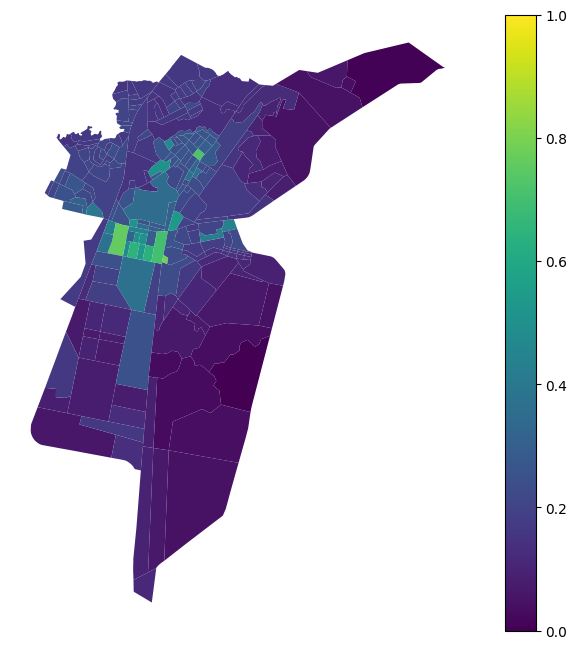

In [ ]:
blocks_gdf[['geometry']].join(centrality_df).plot('services_centrality', legend=True, figsize=(10, 8), vmin=0, vmax=1).set_axis_off()

In [ ]:
#сохранение центральности
blocks_gdf[['geometry']].join(centrality_df).to_file('services_centrality.geojson')